
# " Multiclass classification model to predict breast cancer molecular subtypes using multi-omics data and interpret biological drivers" 

In [12]:
# Load libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Dataset

df =  pd.read_csv("data/data.csv")
df

,rs_CLEC3A,rs_CPB1,rs_SCGB2A2,rs_SCGB1D2,rs_TFF1,rs_MUCL1,rs_GSTM1,rs_PIP,rs_ADIPOQ,rs_ADH1B,...,pp_p62.LCK.ligand,pp_p70S6K,pp_p70S6K.pT389,pp_p90RSK,pp_p90RSK.pT359.S363,vital.status,PR.Status,ER.Status,HER2.Final.Status,histological.type
0,0.892818,6.580103,14.123672,10.606501,13.189237,6.649466,10.520335,10.338490,10.248379,10.229970,...,-0.691766,-0.337863,-0.178503,0.011638,-0.207257,0,Positive,Positive,Negative,infiltrating ductal carcinoma
1,0.000000,3.691311,17.116090,15.517231,9.867616,9.691667,8.179522,7.911723,1.289598,1.818891,...,0.279067,0.292925,-0.155242,-0.089365,0.267530,0,Positive,Negative,Negative,infiltrating ductal carcinoma
2,3.748150,4.375255,9.658123,5.326983,12.109539,11.644307,10.517330,5.114925,11.975349,11.911437,...,0.219910,0.308110,-0.190794,-0.222150,-0.198518,0,Positive,Positive,Negative,infiltrating ductal carcinoma
3,0.000000,18.235519,18.535480,14.533584,14.078992,8.913760,10.557465,13.304434,8.205059,9.211476,...,-0.266554,-0.079871,-0.463237,0.522998,-0.046902,0,Positive,Positive,Negative,infiltrating ductal carcinoma
4,0.000000,4.583724,15.711865,12.804521,8.881669,8.430028,12.964607,6.806517,4.294341,5.385714,...,-0.441542,-0.152317,0.511386,-0.096482,0.037473,0,Positive,Positive,Negative,infiltrating ductal carcinoma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,0.000000,5.004281,12.817877,10.854036,11.293350,4.143573,0.926986,5.818401,12.950524,12.552395,...,-0.993249,0.131803,-0.012965,0.306601,0.344012,0,NaN,NaN,NaN,infiltrating lobular carcinoma
701,2.241901,4.867086,8.875779,5.641164,11.940968,3.149715,4.101322,9.272752,5.335362,6.974459,...,-0.502791,-0.674763,0.165243,-0.338279,0.487583,1,NaN,NaN,NaN,infiltrating lobular carcinoma
702,3.260718,6.700652,14.299072,8.443970,12.312343,11.846810,2.148544,10.435503,3.498442,8.011837,...,0.669064,0.110822,-0.170345,-0.232004,-0.165477,1,NaN,NaN,NaN,infiltrating lobular carcinoma
703,11.766777,6.656791,13.638154,10.618453,13.775750,6.649667,7.340151,9.903519,9.922855,9.360980,...,0.053346,-0.455617,-0.219365,-0.103807,-0.109356,0,NaN,NaN,NaN,infiltrating lobular carcinoma


In [14]:
df.head()

,rs_CLEC3A,rs_CPB1,rs_SCGB2A2,rs_SCGB1D2,rs_TFF1,rs_MUCL1,rs_GSTM1,rs_PIP,rs_ADIPOQ,rs_ADH1B,...,pp_p62.LCK.ligand,pp_p70S6K,pp_p70S6K.pT389,pp_p90RSK,pp_p90RSK.pT359.S363,vital.status,PR.Status,ER.Status,HER2.Final.Status,histological.type
0,0.892818,6.580103,14.123672,10.606501,13.189237,6.649466,10.520335,10.338490,10.248379,10.229970,...,-0.691766,-0.337863,-0.178503,0.011638,-0.207257,0,Positive,Positive,Negative,infiltrating ductal carcinoma
1,0.000000,3.691311,17.116090,15.517231,9.867616,9.691667,8.179522,7.911723,1.289598,1.818891,...,0.279067,0.292925,-0.155242,-0.089365,0.267530,0,Positive,Negative,Negative,infiltrating ductal carcinoma
2,3.748150,4.375255,9.658123,5.326983,12.109539,11.644307,10.517330,5.114925,11.975349,11.911437,...,0.219910,0.308110,-0.190794,-0.222150,-0.198518,0,Positive,Positive,Negative,infiltrating ductal carcinoma
3,0.000000,18.235519,18.535480,14.533584,14.078992,8.913760,10.557465,13.304434,8.205059,9.211476,...,-0.266554,-0.079871,-0.463237,0.522998,-0.046902,0,Positive,Positive,Negative,infiltrating ductal carcinoma
4,0.000000,4.583724,15.711865,12.804521,8.881669,8.430028,12.964607,6.806517,4.294341,5.385714,...,-0.441542,-0.152317,0.511386,-0.096482,0.037473,0,Positive,Positive,Negative,infiltrating ductal carcinoma


In [15]:
df.describe()

,rs_CLEC3A,rs_CPB1,rs_SCGB2A2,rs_SCGB1D2,rs_TFF1,rs_MUCL1,rs_GSTM1,rs_PIP,rs_ADIPOQ,rs_ADH1B,...,pp_p27.pT198,pp_p38.MAPK,pp_p38.pT180.Y182,pp_p53,pp_p62.LCK.ligand,pp_p70S6K,pp_p70S6K.pT389,pp_p90RSK,pp_p90RSK.pT359.S363,vital.status
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,...,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,4.547197,6.487979,9.516678,7.351940,8.179439,7.806726,5.677454,8.721931,7.450675,7.747601,...,0.008589,0.004734,0.059332,-0.094355,0.109583,-0.028409,0.048929,-0.002065,0.019180,0.133333
std,4.971708,4.874769,4.758348,4.248440,4.291915,4.325965,4.331351,4.130467,4.244499,4.245585,...,0.254308,0.302194,0.544589,0.579644,0.811079,0.555587,0.377429,0.345646,0.291446,0.340176
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.918200,-1.432959,-1.637550,-3.017238,-2.646594,-2.152630,-0.751501,-1.334300,-1.182336,0.000000
25%,0.000000,2.297602,5.937361,3.842758,5.144707,4.612299,1.436695,5.784499,4.171967,4.688113,...,-0.141888,-0.168875,-0.276563,-0.302937,-0.426244,-0.317636,-0.207172,-0.232004,-0.147140,0.000000
50%,2.379261,6.002963,10.011822,7.701500,9.043774,7.530813,5.866248,9.305378,7.999344,8.277510,...,-0.022655,0.006428,0.084549,-0.067906,-0.005234,-0.067527,-0.039654,-0.010013,0.006341,0.000000
75%,8.025802,9.503384,13.087360,10.493654,11.536532,11.157128,10.132437,11.948430,10.559780,10.785635,...,0.136848,0.183828,0.413358,0.180853,0.573340,0.206411,0.211573,0.212412,0.172476,0.000000
max,17.432087,20.960773,20.978437,19.979807,17.338611,19.132935,14.702210,18.662764,17.355330,17.892925,...,1.051862,1.483391,2.349841,2.069048,3.043258,2.475027,1.664292,1.545965,1.062551,1.000000


In [ ]:
 # Exploratory data analysis

In [16]:
cols = ['ER.Status', 'PR.Status', 'HER2.Final.Status']

for col in cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False))


ER.Status value counts:
ER.Status
Positive                       414
Negative                       135
NaN                            122
Not Performed                   27
Performed but Not Available      5
Indeterminate                    2
Name: count, dtype: int64

PR.Status value counts:
PR.Status
Positive                       353
Negative                       193
NaN                            122
Not Performed                   28
Performed but Not Available      5
Indeterminate                    4
Name: count, dtype: int64

HER2.Final.Status value counts:
HER2.Final.Status
Negative         457
NaN              145
Positive          86
Equivocal          9
Not Available      8
Name: count, dtype: int64


In [17]:
# Missing Values
df[cols].isnull().sum()

ER.Status            122
PR.Status            122
HER2.Final.Status    145
dtype: int64

In [18]:
# Data Cleaning

valid = ['Positive', 'Negative']

df = df[
    df['ER.Status'].isin(valid) &
    df['PR.Status'].isin(valid) &
    df['HER2.Final.Status'].isin(valid)
].copy()

print("After cleaning:", df.shape)


After cleaning: (507, 1941)


In [20]:
# Subtype Engineering

def assign_subtype(row):
    er = row['ER.Status']
    pr = row['PR.Status']
    her2 = row['HER2.Final.Status']
    
    if er == 'Positive' and pr == 'Positive' and her2 == 'Negative':
        return 'Luminal A'
    elif er == 'Positive' and her2 == 'Positive':
        return 'Luminal B'
    elif er == 'Negative' and pr == 'Negative' and her2 == 'Positive':
        return 'HER2'
    elif er == 'Negative' and pr == 'Negative' and her2 == 'Negative':
        return 'TNBC'
    else:
        return 'Other'

df['Subtype'] = df.apply(assign_subtype, axis=1)

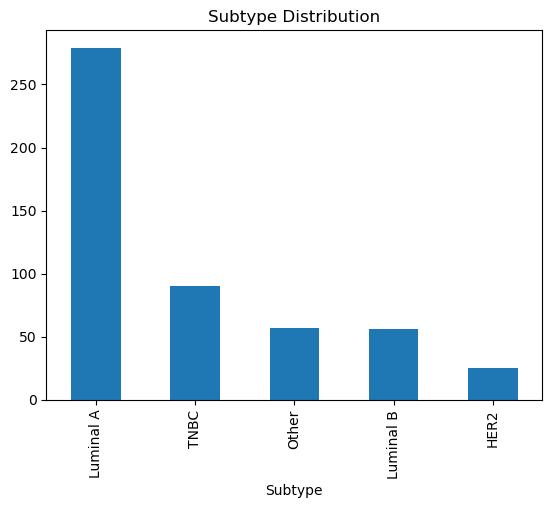

In [ ]:
# Subtype Distribution

df['Subtype'].value_counts().plot(kind='bar')
plt.title("Subtype Distribution")
plt.savefig("/results/Histological_types.jpeg",dpi=300)
plt.show()

# Inference :

1. Dataset is highly imbalanced: Luminal A ~55–60% (≈280 samples) dominates, while HER2 ~5% (≈25 samples) is severely underrepresented

2. Moderate representation of TNBC ~18–20% (≈90 samples) and Luminal B/Other ~10–12% each (≈55–60 samples) indicates uneven class learning difficulty

3. Imbalance ratio between largest and smallest class is ~10:1, requiring class balancing to avoid biased predictions

In [22]:
# Remove “Other”

df = df[df['Subtype'] != 'Other'].copy()

print(df['Subtype'].value_counts())

Subtype
Luminal A    279
TNBC          90
Luminal B     56
HER2          25
Name: count, dtype: int64


# Feature Engineering

In [23]:
# Encode target

le = LabelEncoder()
df['Subtype_encoded'] = le.fit_transform(df['Subtype'])

print(dict(zip(le.classes_, le.transform(le.classes_))))

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", label_mapping)

{'HER2': np.int64(0), 'Luminal A': np.int64(1), 'Luminal B': np.int64(2), 'TNBC': np.int64(3)}
Label Mapping: {'HER2': np.int64(0), 'Luminal A': np.int64(1), 'Luminal B': np.int64(2), 'TNBC': np.int64(3)}


In [24]:
# Define X nad y

# ================================
# 2. Define feature matrix (X)
# ================================
# Drop target + clinical leakage columns

drop_cols = [
    'Subtype',
    'Subtype_encoded',
    'ER.Status',
    'PR.Status',
    'HER2.Final.Status'
]

X = df.drop(columns=drop_cols)

# Remove ALL non-numeric columns
X = X.select_dtypes(exclude=['object'])

y = df['Subtype_encoded']


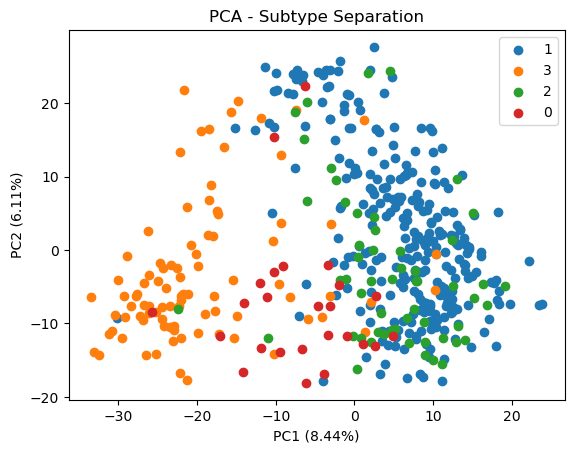

In [ ]:
# PCA – Subtype Separability

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Subtype'] = y.values

# Plot
plt.figure()
for subtype in pca_df['Subtype'].unique():
    subset = pca_df[pca_df['Subtype'] == subtype]
    plt.scatter(subset['PC1'], subset['PC2'], label=subtype)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA - Subtype Separation")
plt.legend()
plt.savefig("/results/PCA_subtype.jpeg",dpi=300)
plt.show()

# Inference :

1. First two components explain ~14.5% variance (PC1: 8.44%, PC2: 6.11%), indicating high data complexity

2. Partial clustering observed, with subtype 1 relatively separable, while others show overlap

3. Suggests need for non-linear models (e.g., XGBoost) for improved subtype discrimination

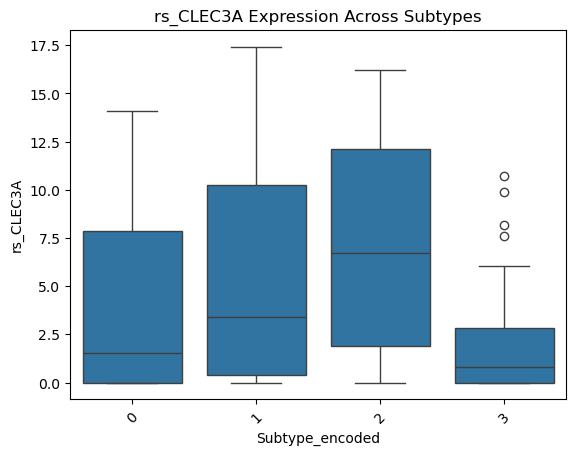

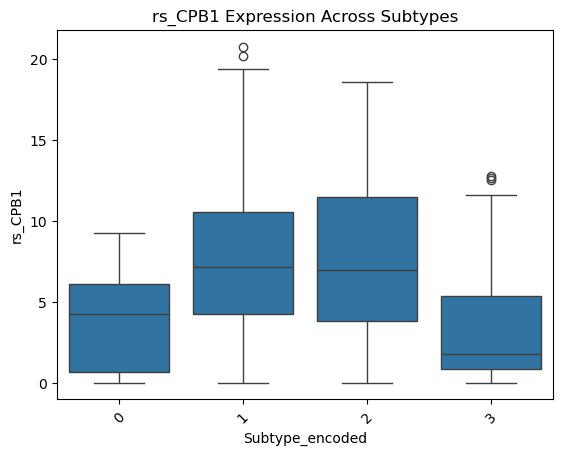

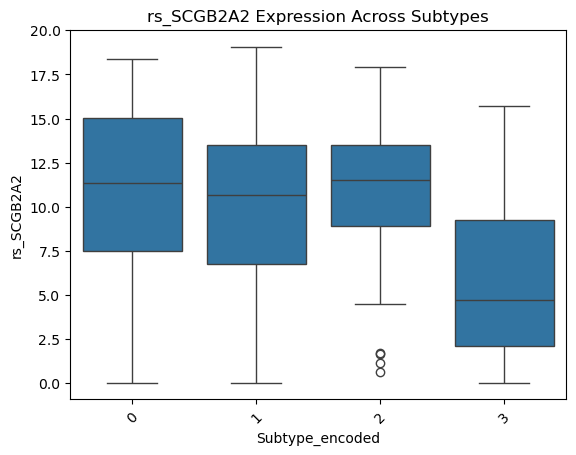

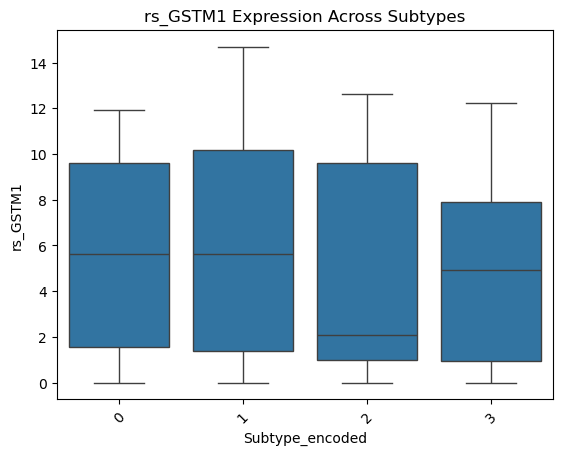

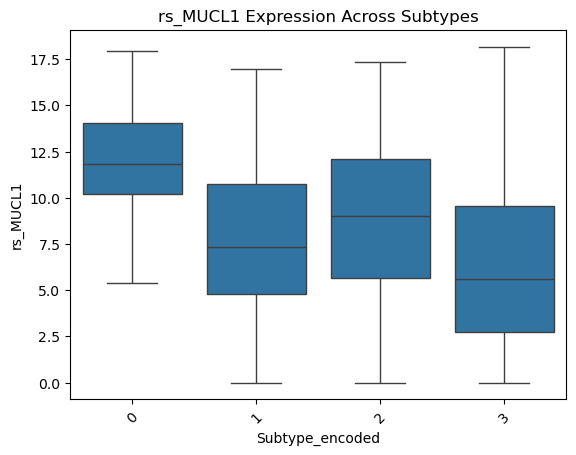


ANOVA Results:
rs_CLEC3A: p-value = 1.1241e-09
rs_CPB1: p-value = 6.1487e-16
rs_SCGB2A2: p-value = 2.0781e-15
rs_GSTM1: p-value = 1.3813e-01
rs_MUCL1: p-value = 1.2134e-07


In [ ]:
# Feature Distribution Across Subtypes

import os
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway

# Define save directory
save_dir = "/results/feature_plots.jpeg"
os.makedirs(save_dir, exist_ok=True)

# Select top variable genes
top_features = X.var().sort_values(ascending=False).head(5).index

# Boxplots + save as JPEG
for gene in top_features:
    plt.figure()
    sns.boxplot(x=y, y=X[gene])
    plt.title(f"{gene} Expression Across Subtypes")
    plt.xticks(rotation=45)

    # Save figure BEFORE show
    file_path = os.path.join(save_dir, f"{gene}_subtype_distribution.jpeg")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')

    plt.show()
    plt.close()

# ANOVA test
print("\nANOVA Results:")
for gene in top_features:
    groups = [X[gene][y == subtype] for subtype in y.unique()]
    stat, p = f_oneway(*groups)
    print(f"{gene}: p-value = {p:.4e}")

# Inference :

1. rs_CLEC3A Expression

Clear subtype-dependent variation with higher median expression in subtype 2 (~6–7) vs subtype 0 (~1–2)

Wide interquartile range indicates high intra-class variability

Likely a moderate discriminatory biomarker, but not sufficient alone


2. rs_CPB1 Expression

Subtypes 1 and 2 show higher median expression (~7–10) compared to subtype 3 (~1–2)

Presence of outliers (>20) suggests strong expression spikes in specific samples

Potential subtype-specific marker, especially distinguishing subtype 3


3. rs_GSTM1 Expression

Comparable medians across subtypes (~4–6), indicating weak discriminatory power

Large spread (0–12 range) suggests high variability without clear subtype separation

Likely contributes as a supporting feature rather than a primary driver


4. rs_MUCL1 Expression

Subtype 0 shows consistently higher median (~11–12) vs subtype 3 (~5–6)

Distinct shift in distribution indicates good subtype separability potential

Strong candidate for feature importance in model interpretation


5. rs_SCGB2A2 Expression

Higher expression in subtypes 0 and 2 (median ~11–12) vs subtype 3 (~4–5)

Presence of low-expression outliers in subtype 2 indicates heterogeneity

Biologically relevant and likely high-impact feature for classification models

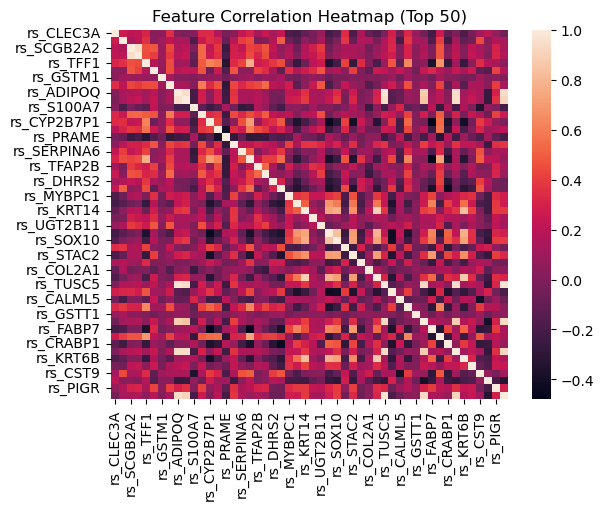

Highly correlated feature pairs (|r| > 0.8):
('rs_SCGB2A2', 'rs_SCGB1D2', np.float64(0.9467648828362525))
('rs_TFF1', 'rs_TFF3', np.float64(0.8466017788272349))
('rs_ADIPOQ', 'rs_ADH1B', np.float64(0.9493328280445982))
('rs_ADIPOQ', 'rs_TUSC5', np.float64(0.9713611283182996))
('rs_ADIPOQ', 'rs_LEP', np.float64(0.8792400831807545))
('rs_ADIPOQ', 'rs_FABP4', np.float64(0.9391755704378224))
('rs_ADIPOQ', 'rs_CIDEC', np.float64(0.940935975779643))
('rs_ADIPOQ', 'rs_GPD1', np.float64(0.9192295693191995))
('rs_ADIPOQ', 'rs_PLIN1', np.float64(0.934162963793824))
('rs_ADIPOQ', 'rs_CIDEA', np.float64(0.9134451942823727))


In [ ]:
# Correlation & Redundancy Analysis

import seaborn as sns
import numpy as np

# Correlation matrix
corr_matrix = X.corr()

# Plot heatmap (subset if too large)
plt.figure()
sns.heatmap(corr_matrix.iloc[:50, :50])  # limit for visualization
plt.title("Feature Correlation Heatmap (Top 50)")
plt.savefig("/results/Feature_correlation.jpeg",dpi=300)
plt.show()

# Identify highly correlated features
threshold = 0.8
high_corr = np.where(np.abs(corr_matrix) > threshold)

high_corr_pairs = [
    (corr_matrix.index[i], corr_matrix.columns[j], corr_matrix.iloc[i, j])
    for i, j in zip(*high_corr) if i < j
]

print("Highly correlated feature pairs (|r| > 0.8):")
for pair in high_corr_pairs[:10]:
    print(pair)



# Inference

1. Majority of feature correlations are low–moderate (|r| < 0.5), indicating low redundancy and high feature diversity

2. Limited clusters of high correlation (|r| > 0.8) suggest localized co-expression modules, not global redundancy

3. Supports use of full feature space or light dimensionality reduction without major information loss

In [31]:
# Class-wise Feature Importance

from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y)
mi_df = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print(mi_df.head(10))

rs_ESR1        0.388328
pp_ER.alpha    0.373453
rs_CYP2B7P1    0.339148
rs_AGR3        0.330932
rs_ERBB4       0.295808
rs_SCUBE2      0.295575
cn_PNMT        0.286839
rs_FSIP1       0.284224
rs_GRPR        0.284001
pp_GATA3       0.282703
dtype: float64


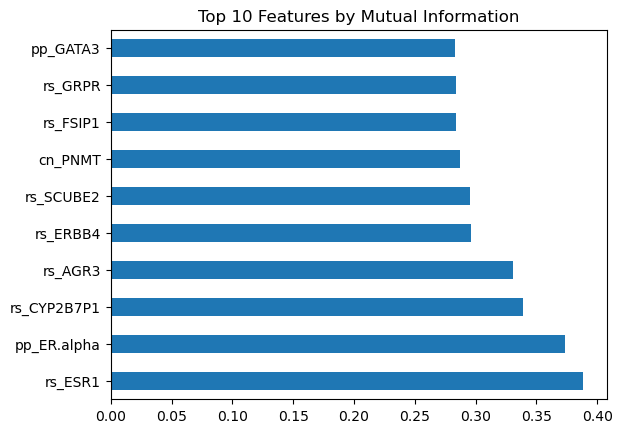

In [ ]:
mi_df.head(10).plot(kind='barh')
plt.title("Top 10 Features by Mutual Information")
plt.savefig("/top10_features.jpeg",dpi=300)
plt.show()

# Inference

1. Top features show high mutual information (0.28–0.39), indicating strong predictive dependency with cancer subtypes

2. Dominance of ER-related genes (ESR1, ER-alpha, GATA3) confirms biologically driven classification signals

3. Feature concentration suggests luminal subtype bias, requiring additional markers for balanced subtype prediction

C:\Users\kiran\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


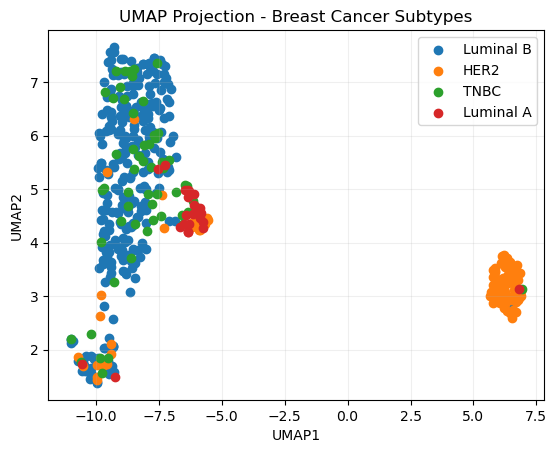

In [ ]:
# UMAP 

import umap

# Label mapping (optional but recommended)
label_map = {
    0: "Luminal A",
    1: "Luminal B",
    2: "TNBC",
    3: "HER2"
}

y_named = pd.Series(y).map(label_map)

# 🔥 Updated UMAP parameters HERE
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)

# Fit-transform
X_umap = reducer.fit_transform(X)

# Plot
plt.figure()

for subtype in y_named.unique():
    idx = y_named == subtype
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], label=subtype)

plt.title("UMAP Projection - Breast Cancer Subtypes")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend()
plt.grid(alpha=0.2)

plt.savefig("/results/UMAP.jpeg",dpi=300)
plt.show()

# Inference :

1. Clear clustering observed with one subtype forming a distinct cluster, indicating strong separability

2. Remaining subtypes show partial overlap, suggesting non-linear decision boundaries

3. Confirms need for advanced models (e.g., XGBoost / ensemble methods) over linear classifiers

In [44]:
# UMAP scoring

from sklearn.metrics import silhouette_score

score = silhouette_score(X_umap, y)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.096


# Inference

1. Low cluster separation (0.096) indicates high overlap between cancer subtypes in unsupervised space

2. Suggests underlying biology is heterogeneous and not linearly separable, especially across Luminal and TNBC groups

3. Confirms necessity of supervised, non-linear models to capture subtype-specific patterns for accurate classification

# Model building

In [51]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
print(X_train.dtypes.value_counts())

int64      1110
float64     827
Name: count, dtype: int64


# Build models

In [ ]:
# =============================
# IMPORTS
# =============================
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

import numpy as np
import pandas as pd

# =============================
# 1.BASE MODELS
# =============================
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    
    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        solver='lbfgs'
    ),
    
    "XGBoost (Original)": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=4,
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=-1
    )
}

predictions = {}

# Train baseline models
for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    predictions[name] = y_pred
    
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(classification_report(y_test, y_pred))

# =============================
# 2.  WEIGHTED XGBOOST (TUNED)
# =============================
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
weight_dict = dict(zip(classes, weights))
sample_weights = np.array([weight_dict[i] for i in y_train])

xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': [300, 500],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0, 1, 2],
    'min_child_weight': [3, 5, 7]
}

search = RandomizedSearchCV(
    xgb_base,
    param_dist,
    n_iter=15,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

search.fit(X_train, y_train, sample_weight=sample_weights)

HT_XGB_wts_model = search.best_estimator_

y_pred_weighted = HT_XGB_wts_model.predict(X_test)

print("\n🔹 XGBoost (Weighted Tuned)")
print("Accuracy:", accuracy_score(y_test, y_pred_weighted))
print(classification_report(y_test, y_pred_weighted))

predictions["XGBoost (Weighted)"] = y_pred_weighted

# =============================
# 3. SMOTE ONLY
# =============================
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_smote.fit(X_train_sm, y_train_sm)

y_pred_smote = xgb_smote.predict(X_test)

print("\n🔹 XGBoost (SMOTE)")
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

predictions["XGBoost (SMOTE)"] = y_pred_smote

# =============================
# 4. SMOTE + WEIGHTS
# =============================
classes_sm = np.unique(y_train_sm)
weights_sm = compute_class_weight('balanced', classes=classes_sm, y=y_train_sm)
weight_dict_sm = dict(zip(classes_sm, weights_sm))
sample_weights_sm = np.array([weight_dict_sm[i] for i in y_train_sm])

xgb_smote_wt = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    min_child_weight=3,
    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_smote_wt.fit(X_train_sm, y_train_sm, sample_weight=sample_weights_sm)

y_pred_smote_wt = xgb_smote_wt.predict(X_test)

print("\n🔹 XGBoost (SMOTE + Weights)")
print("Accuracy:", accuracy_score(y_test, y_pred_smote_wt))
print(classification_report(y_test, y_pred_smote_wt))

predictions["XGBoost (SMOTE + Weights)"] = y_pred_smote_wt

# =============================
# 5.FINAL COMPARISON
# =============================
results = []

for name, y_pred in predictions.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro_F1": report['macro avg']['f1-score'],
        "Weighted_F1": report['weighted avg']['f1-score'],
        "Recall_Class_2": report['2']['recall']
    })

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values(by="Macro_F1", ascending=False)

print("\n===== FINAL MODEL COMPARISON =====\n")
print(comparison_df)


🔹 Training RandomForest...
RandomForest Accuracy: 0.889
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       0.86      1.00      0.93        56
           2       1.00      0.09      0.17        11
           3       1.00      1.00      1.00        18

    accuracy                           0.89        90
   macro avg       0.92      0.77      0.75        90
weighted avg       0.90      0.89      0.85        90


🔹 Training LogisticRegression...
LogisticRegression Accuracy: 0.844
              precision    recall  f1-score   support

           0       0.67      0.40      0.50         5
           1       0.88      0.95      0.91        56
           2       0.50      0.27      0.35        11
           3       0.86      1.00      0.92        18

    accuracy                           0.84        90
   macro avg       0.73      0.65      0.67        90
weighted avg       0.82      0.84      0.82        90


🔹 T

# Inference : Final Model Comparison 


1. XGBoost (Original) is the optimal deployment model

Accuracy: 0.922 | Macro F1: 0.861 (highest)

Maintains balanced performance across classes with acceptable minority recall (Class 2: 0.45)

Demonstrates strong ability to capture non-linear multi-omics relationships, Selected as final production model

2. Class weighting improves minority recall but reduces overall performance

Class 2 Recall: ↑ 0.45 → 0.55 (best)

Macro F1: ↓ 0.86 → 0.77

Indicates improved fairness but loss in global predictive power , Suitable for recall-critical scenarios, not for general deployment


3. SMOTE-based models do not improve performance

SMOTE Accuracy: 0.911 | Macro F1: 0.826

Class 2 Recall: ↓ 0.36 (worse than baseline)

SMOTE + weights further reduces performance (Macro F1: 0.818), Synthetic oversampling introduces noise in complex biological data


4. Ensemble trees outperform classical models

RandomForest: Accuracy 0.889, but Class 2 Recall: 0.09 (failure)

LogisticRegression: Macro F1 0.672 (lowest), Confirms need for boosting-based models for multi-omics classification


5. Clear trade-off between accuracy and class balance

High-performance model → better Macro F1 (0.86)

Balanced models → better minority recall (~0.55) but lower overall metrics,  Highlights bias–variance–imbalance trade-off


6. Final Production Decision

Primary model: XGBoost (Original)

Use case dependent alternative: Weighted XGBoost (if recall prioritized)

Rejected: SMOTE-based approaches


Conclusion :

“XGBoost achieved the best overall performance (Accuracy ~0.92, Macro F1 ~0.86), while imbalance handling methods improved minority recall at the cost of global model efficiency, with SMOTE failing to provide additional benefit.”

# =========================================
# SHAP Analysis (XGBoost - final Model)
# =========================================


===== OMICS CONTRIBUTION =====

             Omics  Contribution (%)
0  Transcriptomics         62.682926
1       Proteomics         37.026615
3         Mutation          0.290459
2              CNV          0.000000


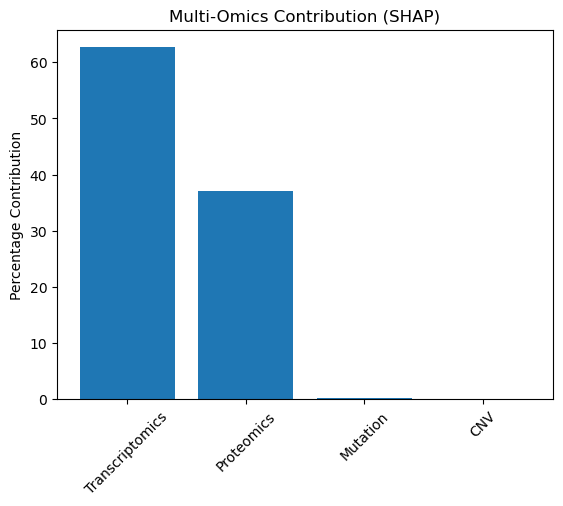

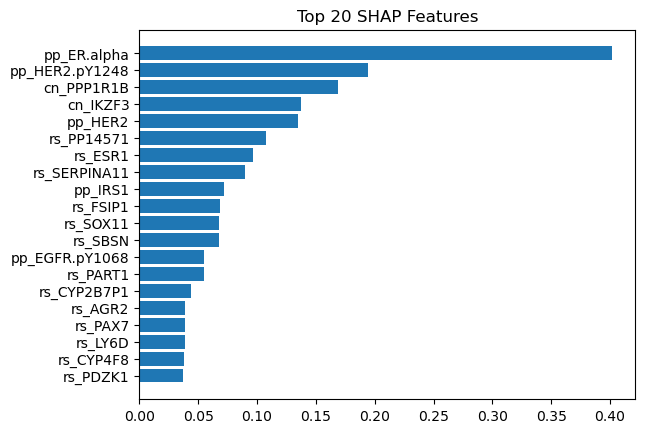

In [ ]:
import shap
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Select trained model
# -----------------------------
final_model = models["XGBoost (Original)"]  # already fitted

# -----------------------------
# 2. Create SHAP explainer
# -----------------------------
explainer = shap.TreeExplainer(final_model)

# -----------------------------
# 3. Compute SHAP values
# -----------------------------
shap_values = explainer.shap_values(X_test)

# -----------------------------
# 4. Save path
# -----------------------------
SAVE_DIR = "/results/shap_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

# -----------------------------
# 5️. Handle SHAP shape safely
# -----------------------------
if isinstance(shap_values, list):
    shap_array = np.array(shap_values)
else:
    shap_array = shap_values

# Convert shape (classes, samples, features) → (samples, features, classes)
if shap_array.shape[0] == len(np.unique(y_test)):
    shap_array = np.transpose(shap_array, (1, 2, 0))

# -----------------------------
# 6️. Aggregate SHAP
# -----------------------------
mean_shap = np.mean(np.abs(shap_array), axis=2)
feature_importance = mean_shap.mean(axis=0)

df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": feature_importance
})

# -----------------------------
# 7️. Omics grouping
# -----------------------------
gene_cols = [c for c in X_test.columns if c.startswith('rs_')]
protein_cols = [c for c in X_test.columns if c.startswith('pp_')]
cnv_cols = [c for c in X_test.columns if c.startswith('cnv_')]
mutation_cols = [c for c in X_test.columns if c.startswith('mu_')]

gene_contrib = df[df['feature'].isin(gene_cols)]['importance'].sum()
protein_contrib = df[df['feature'].isin(protein_cols)]['importance'].sum()
cnv_contrib = df[df['feature'].isin(cnv_cols)]['importance'].sum()
mutation_contrib = df[df['feature'].isin(mutation_cols)]['importance'].sum()

total = gene_contrib + protein_contrib + cnv_contrib + mutation_contrib

contrib_df = pd.DataFrame({
    "Omics": ["Transcriptomics", "Proteomics", "CNV", "Mutation"],
    "Contribution (%)": [
        (gene_contrib/total)*100,
        (protein_contrib/total)*100,
        (cnv_contrib/total)*100,
        (mutation_contrib/total)*100
    ]
}).sort_values(by="Contribution (%)", ascending=False)

print("\n===== OMICS CONTRIBUTION =====\n")
print(contrib_df)

# -----------------------------
# 8️. Save contribution plot
# -----------------------------
plt.figure()
plt.bar(contrib_df["Omics"], contrib_df["Contribution (%)"])
plt.title("Multi-Omics Contribution (SHAP)")
plt.ylabel("Percentage Contribution")
plt.xticks(rotation=45)

plt.savefig(os.path.join(SAVE_DIR, "omics_contribution.jpeg"),
            dpi=300, bbox_inches='tight')

plt.show()
plt.close()

# -----------------------------
# 9️. Save top features
# -----------------------------
top_df = df.sort_values(by="importance", ascending=False).head(20)

plt.figure()
plt.barh(top_df["feature"], top_df["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 SHAP Features")

plt.savefig(os.path.join(SAVE_DIR, "top20_shap_features.jpeg"),
            dpi=300, bbox_inches='tight')

plt.show()
plt.close()

# Inference :

1. Figure1 :  “Model decisions are predominantly driven by transcriptomic signals (~63%), with proteomics providing complementary predictive power (~37%), while genomic alterations (CNV, mutations) contribute minimally.”

2. Figure 2: Top 20 SHAP Features

1. Hormone receptor axis dominates (ER / HER2)
Top features:
pp_ER.alpha (~0.40, highest)
pp_HER2.pY1248
pp_HER2
rs_ESR1

Confirms model captures clinically validated biomarkers

2. Mixed omics features drive prediction
Features include:
Proteomics (pp_*)
Transcriptomics (rs_*)
CNV (cn_*)

Validates multi-omics integration is effective

3. Known cancer genes emerge as key drivers

Examples: ESR1, ERBB2/HER2, EGFR, SOX11
Indicates: Model is biologically interpretable, not black-box

# Insight

“Top SHAP features are dominated by clinically relevant biomarkers (ER, HER2), demonstrating that the model captures biologically meaningful and clinically validated subtype drivers.”


===== TOP FEATURES: Luminal_A =====

             feature  importance
1788     pp_ER.alpha    0.465954
99      rs_SERPINA11    0.344656
1808         pp_HER2    0.340534
1809  pp_HER2.pY1248    0.167566
1209      cn_PPP1R1B    0.147693
1784  pp_EGFR.pY1068    0.140981
466         rs_SOX11    0.069620
1780        pp_DUSP4    0.058257
1219        cn_KRT14    0.044460
319          rs_PNMT    0.044459
137          rs_ESR1    0.041115
297        rs_TUBA3D    0.040853
53         rs_HOXB13    0.040190
163         rs_NBPF4    0.036349
1210         cn_PNMT    0.035433


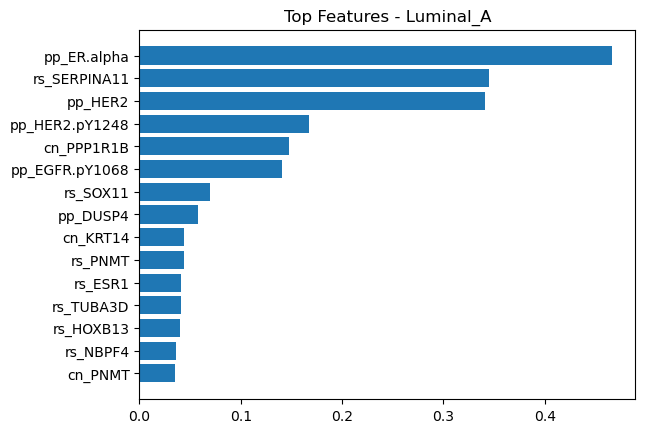


===== TOP FEATURES: Luminal_B =====

                 feature  importance
1788         pp_ER.alpha    0.825694
1809      pp_HER2.pY1248    0.243285
1209          cn_PPP1R1B    0.224542
1818             pp_IRS1    0.214834
466             rs_SOX11    0.180410
314          rs_FLJ45983    0.144401
1815           pp_IGFBP2    0.132149
139             rs_PDZK1    0.115339
17               rs_AGR3    0.114831
544             rs_TNNI3    0.114023
1855  pp_PKC.alpha.pS657    0.106487
1802            pp_GATA3    0.098646
137              rs_ESR1    0.095181
123           rs_SLITRK6    0.091621
1760             pp_CDK1    0.089975


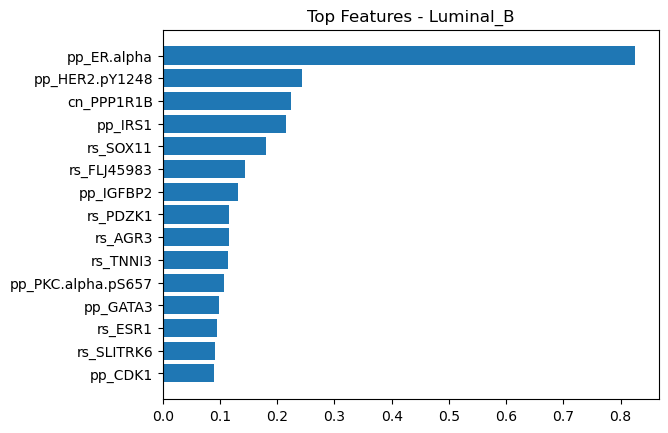


===== TOP FEATURES: TNBC =====

                    feature  importance
1211               cn_IKZF3    0.503133
1209             cn_PPP1R1B    0.267354
294                rs_FSIP1    0.239899
1809         pp_HER2.pY1248    0.220835
72                rs_CYP4F8    0.143412
1208               cn_STAC2    0.139558
1860               pp_PRDX1    0.137826
115                  rs_CA9    0.093745
337               rs_PCSK1N    0.092636
18                rs_TFAP2B    0.090923
209               rs_SLC7A4    0.086775
1814  pp_IGF1R.pY1135.Y1136    0.082279
350                 rs_KRT4    0.081083
273                rs_ROBO2    0.080890
419               rs_MS4A8B    0.080824


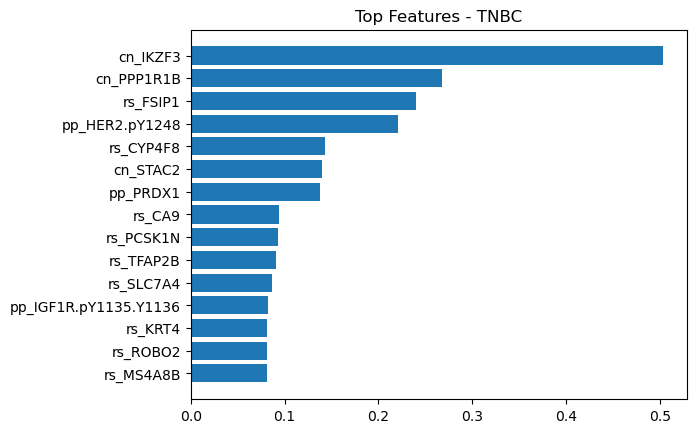


===== TOP FEATURES: HER2 =====

             feature  importance
411       rs_PP14571    0.426764
1788     pp_ER.alpha    0.287533
137          rs_ESR1    0.232735
479         rs_PART1    0.211318
462          rs_SBSN    0.196760
1809  pp_HER2.pY1248    0.146267
63           rs_AGR2    0.144062
40          rs_FABP7    0.135091
298         rs_FOXA1    0.122323
1808         pp_HER2    0.118617
12       rs_CYP2B7P1    0.114906
456         rs_MKRN3    0.110009
78           rs_ELF5    0.093016
191          rs_LY6D    0.090706
1729           pp_AR    0.088529


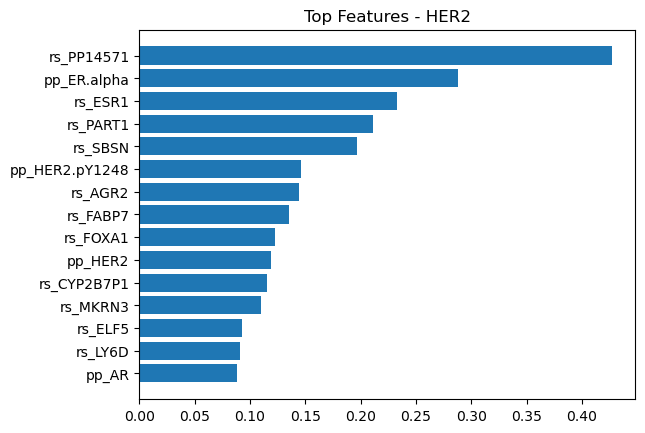

In [ ]:
# CLASS-WISE SHAP

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# =============================
# 1️. Select trained model
# =============================
final_model = models["XGBoost (Original)"]  # already trained

# =============================
# 2️. SHAP Explainer
# =============================
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# =============================
# 3️. Fix SHAP shape
# =============================
if isinstance(shap_values, list):
    shap_array = np.array(shap_values)  # (classes, samples, features)
else:
    shap_array = shap_values

# Convert to (samples, features, classes)
if shap_array.shape[0] == len(np.unique(y_test)):
    shap_array = np.transpose(shap_array, (1, 2, 0))

# =============================
# 4️. Define class names
# =============================
class_names = {
    0: "Luminal_A",
    1: "Luminal_B",
    2: "TNBC",
    3: "HER2"
}

# =============================
# 5️. Save path
# =============================
SAVE_DIR = "/results/shap_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

# =============================
# 6️. Class-wise SHAP analysis
# =============================
n_classes = shap_array.shape[2]

for class_idx in range(n_classes):
    
    class_name = class_names[class_idx]
    
    # Extract SHAP for this class
    class_shap = np.abs(shap_array[:, :, class_idx])
    
    # Feature importance
    feature_importance = class_shap.mean(axis=0)
    
    df_class = pd.DataFrame({
        "feature": X_test.columns,
        "importance": feature_importance
    }).sort_values(by="importance", ascending=False)
    
    # Top 15 features
    top_df = df_class.head(15)
    
    print(f"\n===== TOP FEATURES: {class_name} =====\n")
    print(top_df)
    
    # -----------------------------
    # Plot Top Features
    # -----------------------------
    plt.figure()
    plt.barh(top_df["feature"], top_df["importance"])
    plt.gca().invert_yaxis()
    plt.title(f"Top Features - {class_name}")
    
    plt.savefig(
        os.path.join(SAVE_DIR, f"top_features_{class_name}.jpeg"),
        dpi=300,
        bbox_inches='tight'
    )
    
    plt.show()
    plt.close()
    
    # -----------------------------
    # SHAP Summary Plot
    # -----------------------------
    shap.summary_plot(
        shap_array[:, :, class_idx],
        X_test,
        show=False
    )
    
    plt.title(f"SHAP Summary - {class_name}")
    
    plt.savefig(
        os.path.join(SAVE_DIR, f"summary_{class_name}.jpeg"),
        dpi=300,
        bbox_inches='tight'
    )
    
    plt.close()

In [ ]:
# Inference : Class-wise SHAP 

1. Luminal A — Hormone-Driven, Stable Phenotype
Key Drivers:
pp_ER.alpha (0.46) - dominant
rs_SERPINA11 (0.34)
pp_HER2 / pY1248 (~0.34 / 0.16)
rs_ESR1 (~0.04)

# Interpretation:
Strong ER signaling dominance
HER2 present but secondary
Presence of GATA/HOX/SOX axis → differentiation signals

# Inference:
“Luminal A subtype is primarily driven by estrogen receptor signaling with moderate HER2 contribution, reflecting a hormonally regulated and less aggressive tumor phenotype.”

2. Luminal B — Proliferative, Aggressive Hormone Subtype
Key Drivers:
pp_ER.alpha (0.82) - extremely dominant
pp_HER2.pY1248 (0.24)
pp_IRS1 (0.21), IGFBP2 (0.13)
pp_CDK1 (cell cycle)

# Interpretation:
ER still dominant 
Strong growth signaling (IGF, IRS1)
Active cell cycle (CDK1)

# Inference:
“Luminal B subtype exhibits amplified ER signaling combined with proliferative and growth factor pathways, indicating a more aggressive hormone-responsive phenotype.”

3. TNBC — Genomic Instability + Basal Biology
Key Drivers:
cn_IKZF3 (0.50) - strongest
cn_PPP1R1B (0.26)
rs_FSIP1 (0.24)
rs_CA9 (hypoxia marker)
IGF1R signaling

# Interpretation:
Dominated by CNV signals → genomic instability
Hypoxia + basal markers present
Less hormone/protein signaling

# Inference:
“TNBC is primarily driven by genomic instability and copy number alterations, with additional contributions from hypoxia and basal-like pathways, consistent with an aggressive and non-hormonal phenotype.”

4. HER2 Subtype — Mixed but HER2-Driven Signaling
Key Drivers:
rs_PP14571 (0.42)
pp_ER.alpha (0.28)
rs_ESR1 (0.23)
pp_HER2 / pY1248 (~0.12–0.14)

# Interpretation:
HER2 present but not sole driver
Strong cross-talk with ER pathway
Mixed regulatory network

# Inference:
“HER2 subtype exhibits combined HER2 and estrogen receptor signaling, indicating pathway cross-talk and complex regulatory interactions rather than isolated HER2 dominance.”

# Cross-Subtype Insights (Very Important)

1. ER signaling is globally dominant
Appears in all subtypes (even HER2)- Explains model bias toward luminal classes

2. TNBC is fundamentally different
Only subtype dominated by: CNV , Hypoxia- Clear biological separation

3. HER2 is not purely HER2-driven
Strong ER contribution- Matches real-world biology (HER2+/ER+ overlap)

# Final Insight

“Class-wise SHAP analysis reveals subtype-specific molecular drivers: Luminal subtypes are ER-dominated, TNBC is driven by genomic instability and hypoxia, and HER2 exhibits pathway cross-talk with ER signaling, demonstrating biologically consistent and interpretable model behavior.”


Classes: [0 1 2 3]

===== GLOBAL SHAP =====



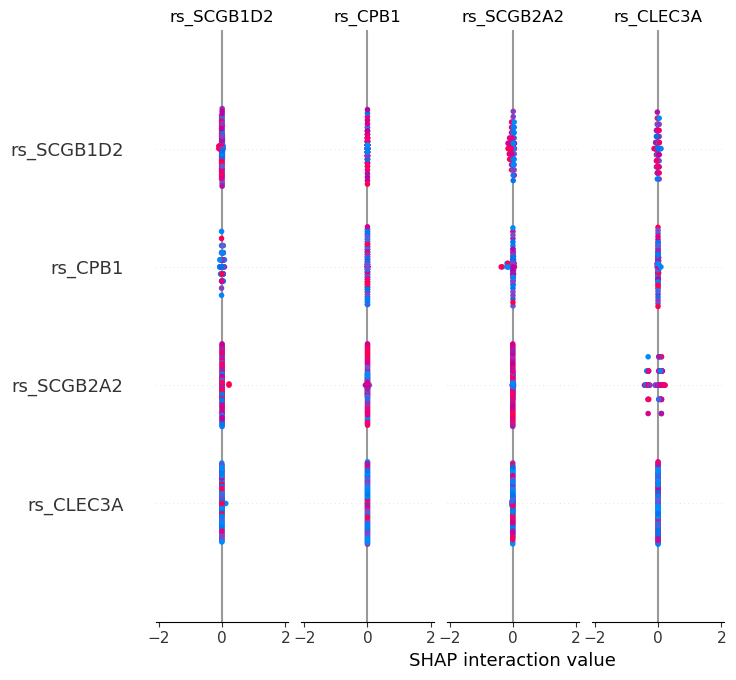


===== CLASS-WISE SHAP =====


--- HER2 ---



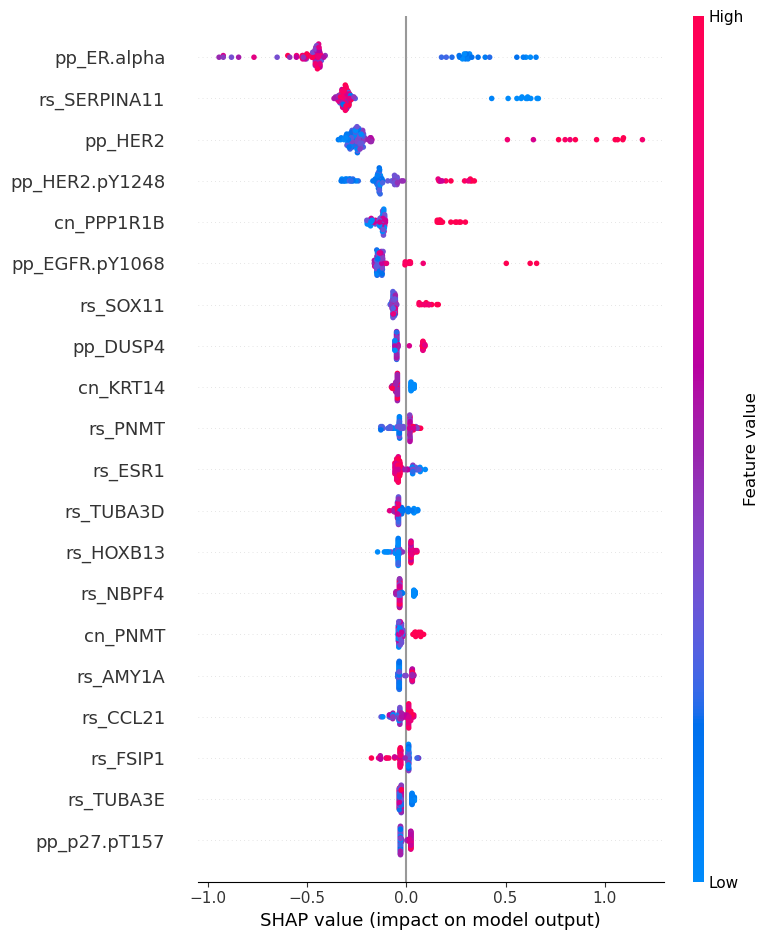


--- Luminal A ---



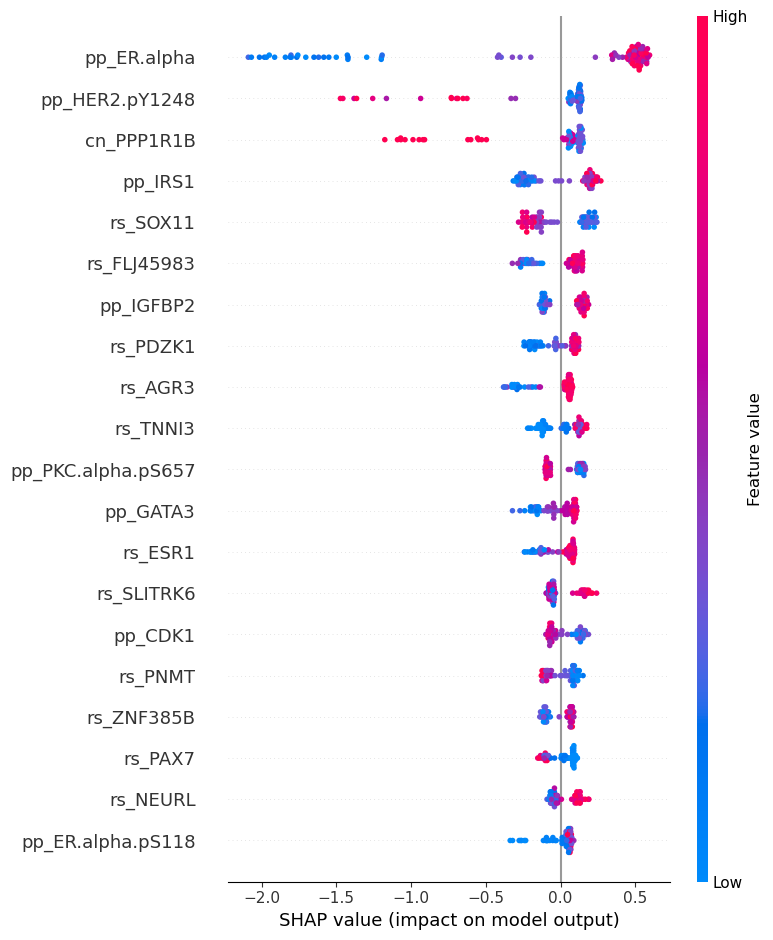


--- Luminal B ---



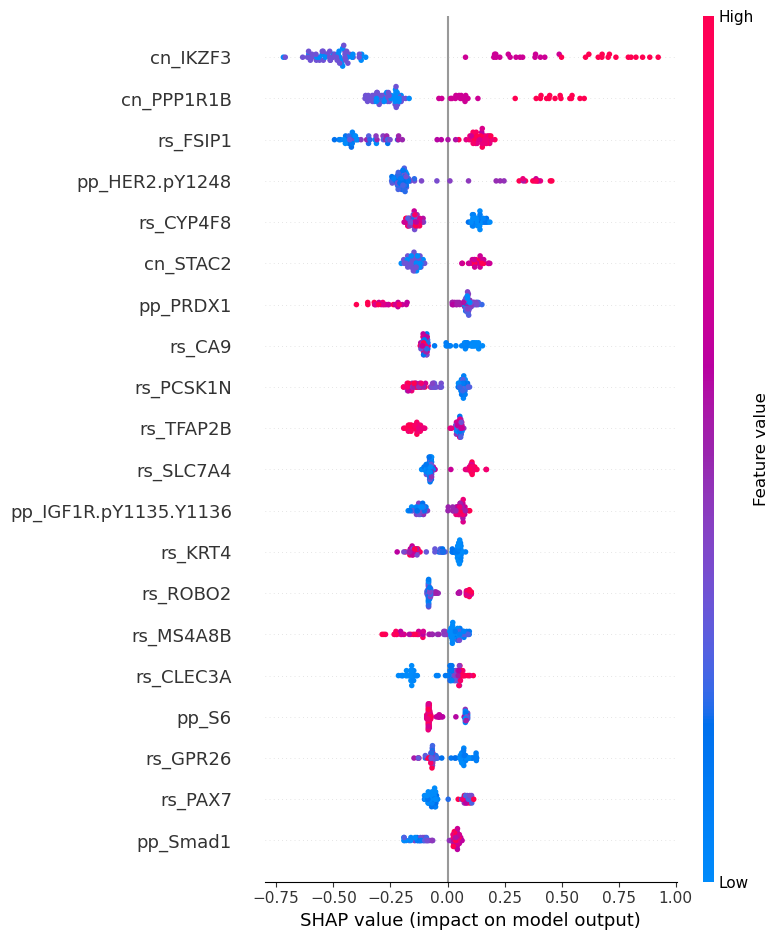


--- TNBC ---



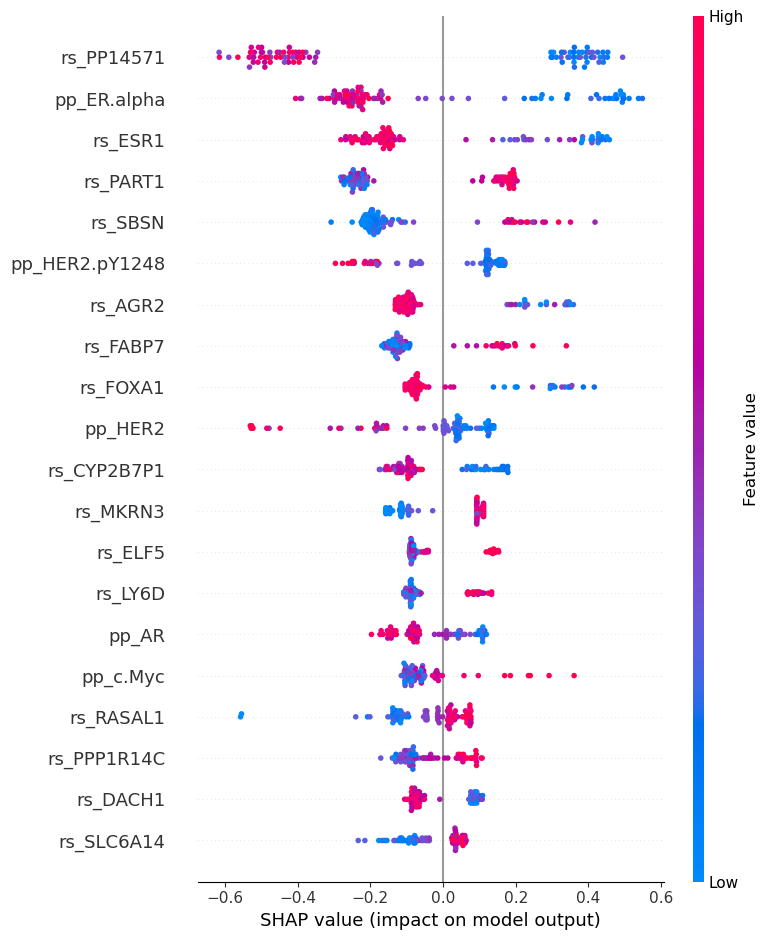

In [ ]:
# =========================================
# SHAP (GLOBAL + CLASS-WISE) - FINAL FIX
# =========================================

import shap
import numpy as np

# -----------------------------
# 1️. Use TRAINED model (FIX)
# -----------------------------
final_model = models["XGBoost (Original)"]   # already trained

# -----------------------------
# 2️. SHAP Explainer
# -----------------------------
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# -----------------------------
# 3️. Check class labels
# -----------------------------
print("Classes:", np.unique(y_test))

# Update if needed
class_names = ['HER2', 'Luminal A', 'Luminal B', 'TNBC']

# -----------------------------
# 4️. GLOBAL SHAP (ALL CLASSES)
# -----------------------------
print("\n===== GLOBAL SHAP =====\n")

shap.summary_plot(shap_values, X_test)


# -----------------------------
# 5️. CLASS-WISE SHAP
# -----------------------------
print("\n===== CLASS-WISE SHAP =====\n")

# Case 1: SHAP returns list (most common)
if isinstance(shap_values, list):
    
    for i, class_name in enumerate(class_names):
        print(f"\n--- {class_name} ---\n")
        shap.summary_plot(shap_values[i], X_test)

# Case 2: SHAP returns array
else:
    
    for i, class_name in enumerate(class_names):
        print(f"\n--- {class_name} ---\n")
        shap.summary_plot(shap_values[:, :, i], X_test)

In [82]:
pivot_df = final_biomarker_df.pivot(index="Feature", columns="Subtype", values="Importance")
print(pivot_df.head())

Subtype         HER2  Luminal_A  Luminal_B  TNBC
Feature                                         
cn_IKZF3         NaN        NaN   0.503133   NaN
cn_KRT14    0.044460        NaN        NaN   NaN
cn_PPP1R1B  0.147693   0.224542   0.267354   NaN
cn_STAC2         NaN        NaN   0.139558   NaN
pp_DUSP4    0.058257        NaN        NaN   NaN


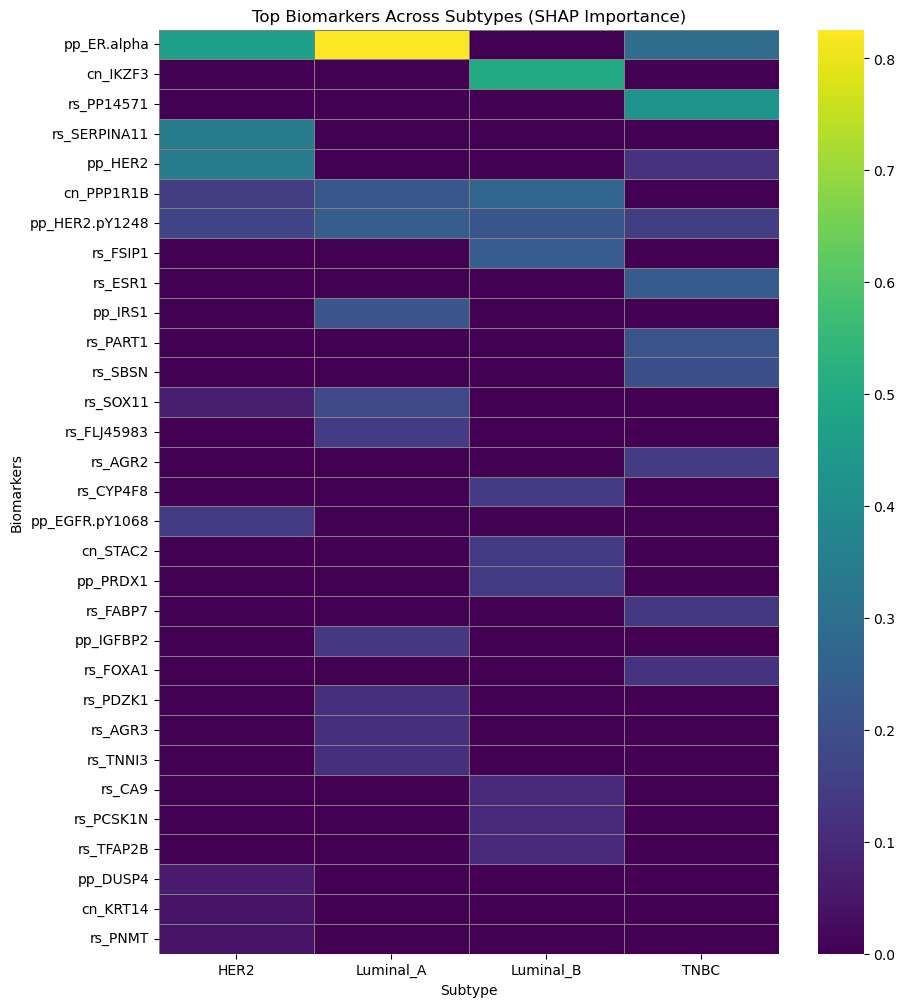

In [ ]:
# Heatmap

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

# -----------------------------
# 1️. Pivot table (Feature × Subtype)
# -----------------------------
heatmap_df = final_biomarker_df.pivot_table(
    index="Feature",
    columns="Subtype",
    values="Importance",
    fill_value=0
)

# -----------------------------
# 2️. Sort features (optional but improves clarity)
# -----------------------------
heatmap_df = heatmap_df.loc[heatmap_df.max(axis=1).sort_values(ascending=False).index]

# -----------------------------
# 3️. Plot heatmap
# -----------------------------
plt.figure(figsize=(10, 12))

sns.heatmap(
    heatmap_df,
    cmap="viridis",
    linewidths=0.5,
    linecolor='gray'
)

plt.title("Top Biomarkers Across Subtypes (SHAP Importance)")
plt.xlabel("Subtype")
plt.ylabel("Biomarkers")

# -----------------------------
# 4️. Save figure
# -----------------------------
SAVE_PATH = "/results/shap_outputs/biomarker_heatmap.jpeg"

os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

plt.savefig(
    SAVE_PATH,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

# Gene ontology, enrichment and pathway analsyis

Total genes used for enrichment: 19

Results saved successfully!


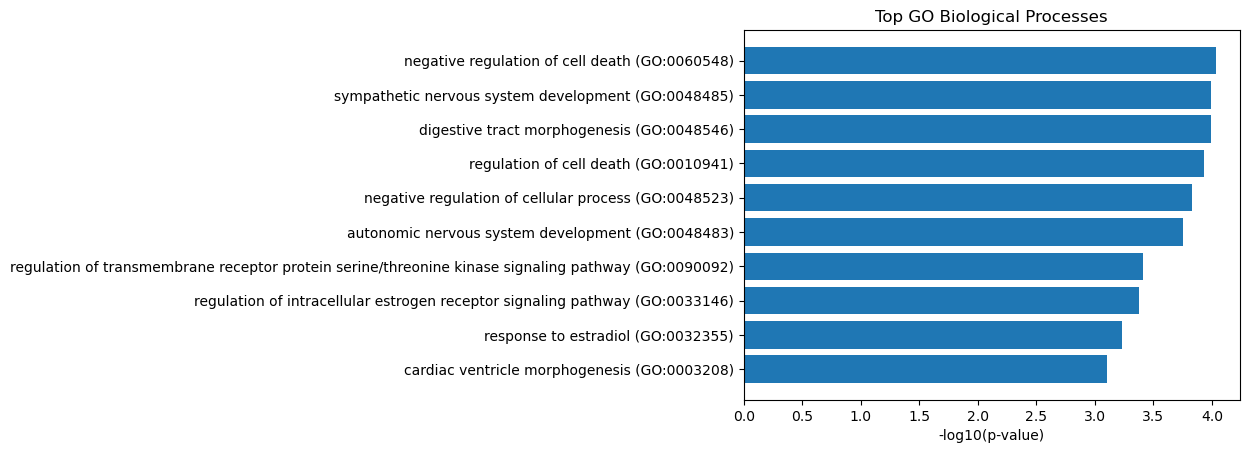

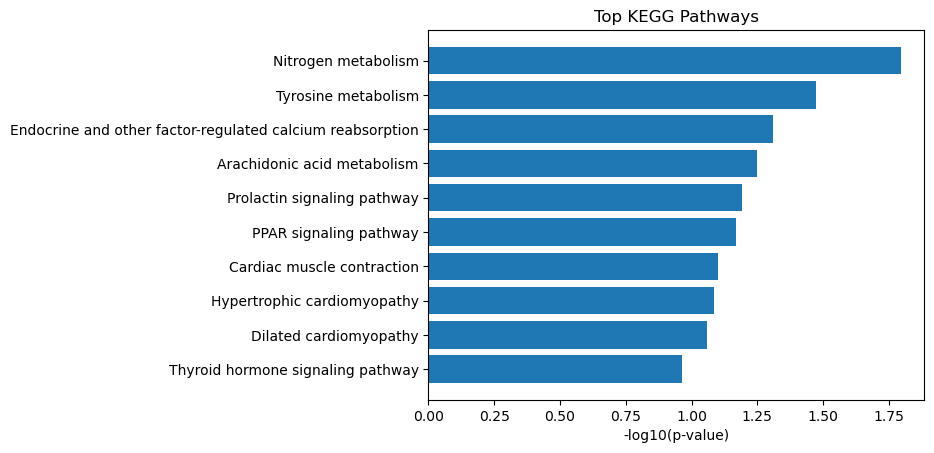


===== TOP GO TERMS =====

                                                Term   P-value
0     negative regulation of cell death (GO:0060548)  0.000092
1  sympathetic nervous system development (GO:004...  0.000102
2         digestive tract morphogenesis (GO:0048546)  0.000102
3              regulation of cell death (GO:0010941)  0.000118
4  negative regulation of cellular process (GO:00...  0.000149
5  autonomic nervous system development (GO:0048483)  0.000178
6  regulation of transmembrane receptor protein s...  0.000391
7  regulation of intracellular estrogen receptor ...  0.000417
8                 response to estradiol (GO:0032355)  0.000589
9       cardiac ventricle morphogenesis (GO:0003208)  0.000790

===== TOP KEGG PATHWAYS =====

                                                Term   P-value
0                                Nitrogen metabolism  0.016034
1                                Tyrosine metabolism  0.033666
2  Endocrine and other factor-regulated calcium r...  0.049

In [ ]:
# =========================================
# GO + KEGG ENRICHMENT (FROM SHAP BIOMARKERS)
# =========================================

import pandas as pd
import numpy as np
import gseapy as gp
import matplotlib.pyplot as plt
import os

# -----------------------------
# 1️. Extract gene list (rs_ only)
# -----------------------------
gene_df = final_biomarker_df[
    final_biomarker_df["Feature"].str.startswith("rs_")
].copy()

# Remove prefix
gene_df["Gene"] = gene_df["Feature"].str.replace("rs_", "", regex=False)

# Unique gene list
gene_list = gene_df["Gene"].dropna().unique().tolist()

print("Total genes used for enrichment:", len(gene_list))


# -----------------------------
# 2️. Run GO enrichment (FIXED)
# -----------------------------
go_results = gp.enrichr(
    gene_list=gene_list,
    organism='human',   # ✅ FIX
    gene_sets='GO_Biological_Process_2021',
    cutoff=0.05
)

# -----------------------------
# 3️. Run KEGG enrichment (FIXED)
# -----------------------------
kegg_results = gp.enrichr(
    gene_list=gene_list,
    organism='human',   # ✅ FIX
    gene_sets='KEGG_2021_Human',
    cutoff=0.05
)

# -----------------------------
# 4️. Save results
# -----------------------------
SAVE_DIR = "/results/shap_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

go_results.results.to_csv(f"{SAVE_DIR}/GO_results.csv", index=False)
kegg_results.results.to_csv(f"{SAVE_DIR}/KEGG_results.csv", index=False)

print("\nResults saved successfully!")


# -----------------------------
# 5️. Plot GO (Top 10)
# -----------------------------
top_go = go_results.results.head(10)

plt.figure()
plt.barh(top_go["Term"], -np.log10(top_go["P-value"]))
plt.gca().invert_yaxis()
plt.xlabel("-log10(p-value)")
plt.title("Top GO Biological Processes")

plt.savefig(f"{SAVE_DIR}/GO_barplot.jpeg", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


# -----------------------------
# 6️. Plot KEGG (Top 10)
# -----------------------------
top_kegg = kegg_results.results.head(10)

plt.figure()
plt.barh(top_kegg["Term"], -np.log10(top_kegg["P-value"]))
plt.gca().invert_yaxis()
plt.xlabel("-log10(p-value)")
plt.title("Top KEGG Pathways")

plt.savefig(f"{SAVE_DIR}/KEGG_barplot.jpeg", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


# -----------------------------
# 7️. Print summary
# -----------------------------
print("\n===== TOP GO TERMS =====\n")
print(top_go[["Term", "P-value"]])

print("\n===== TOP KEGG PATHWAYS =====\n")
print(top_kegg[["Term", "P-value"]])

# Inference :
“Enrichment analysis reveals that SHAP-derived biomarkers are significantly associated with cell survival, estrogen signaling, and metabolic regulation pathways, confirming that the model captures core oncogenic and hormone-driven mechanisms underlying breast cancer subtypes.”


===== PROCESSING: HER2 =====

HER2 genes: 50


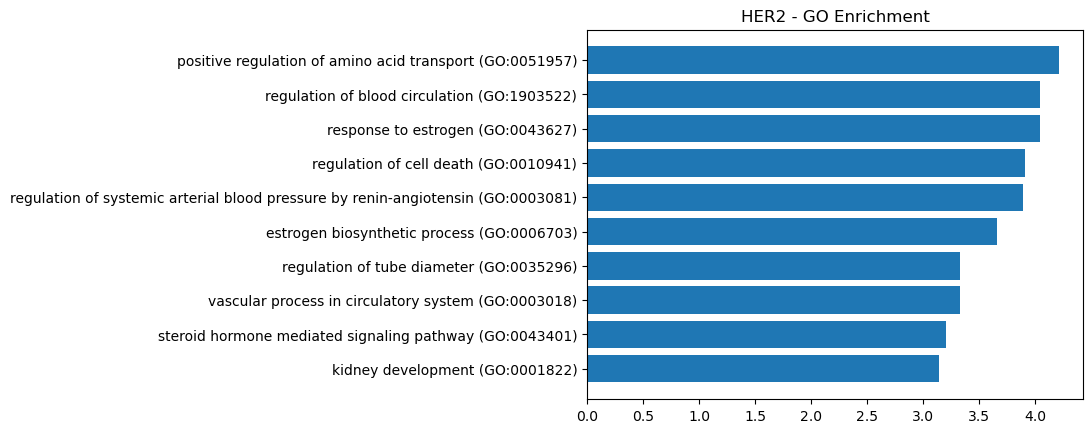

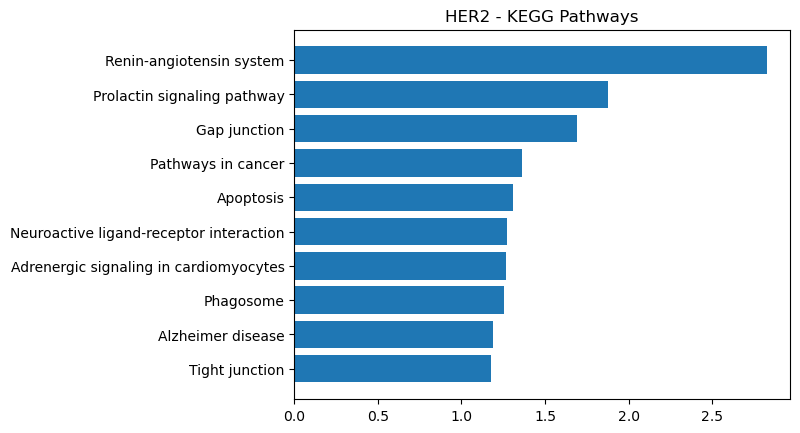


===== PROCESSING: Luminal_A =====

Luminal_A genes: 50


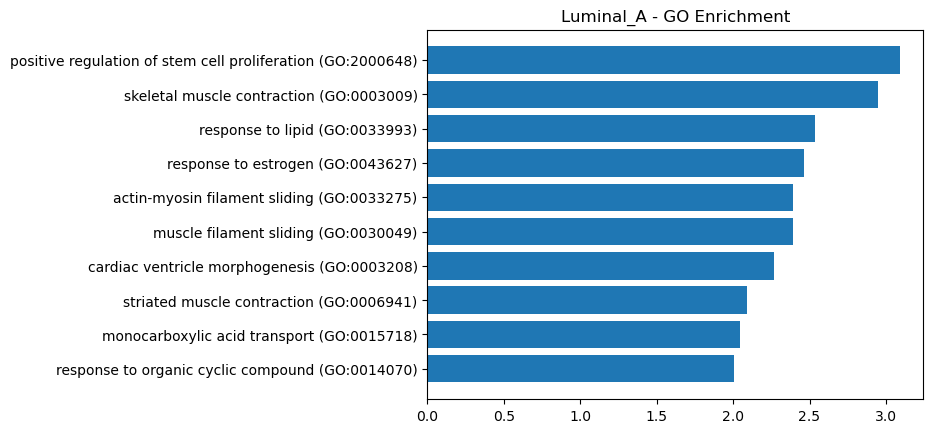

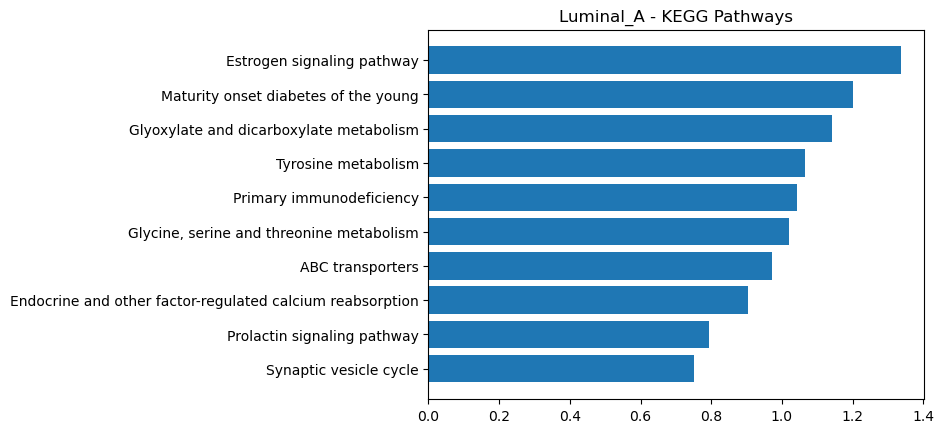


===== PROCESSING: Luminal_B =====

Luminal_B genes: 50


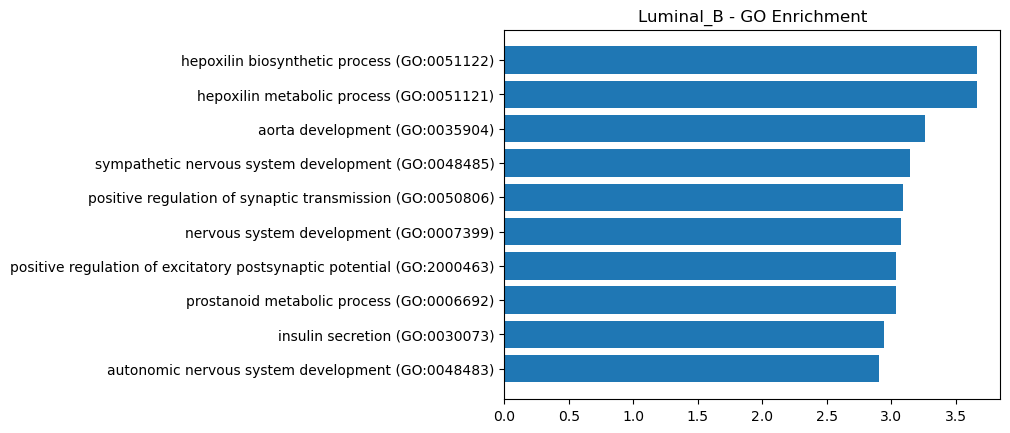

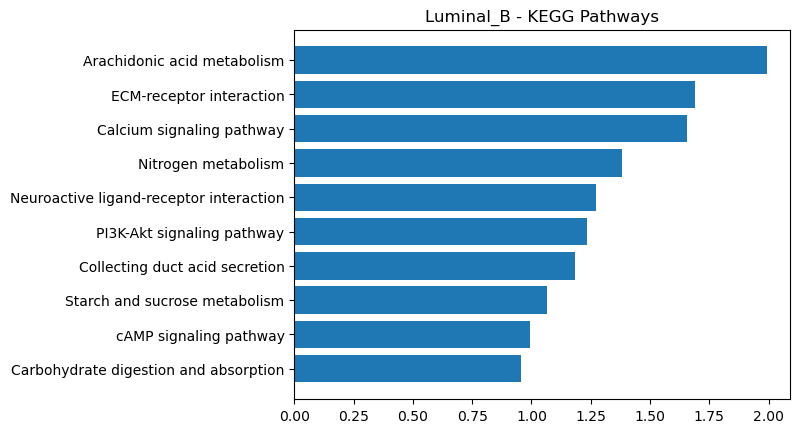


===== PROCESSING: TNBC =====

TNBC genes: 50


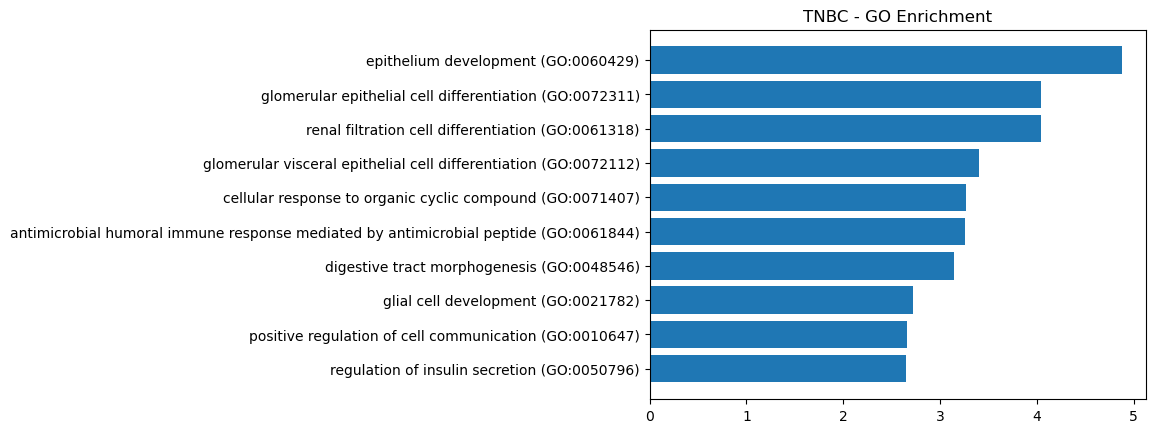

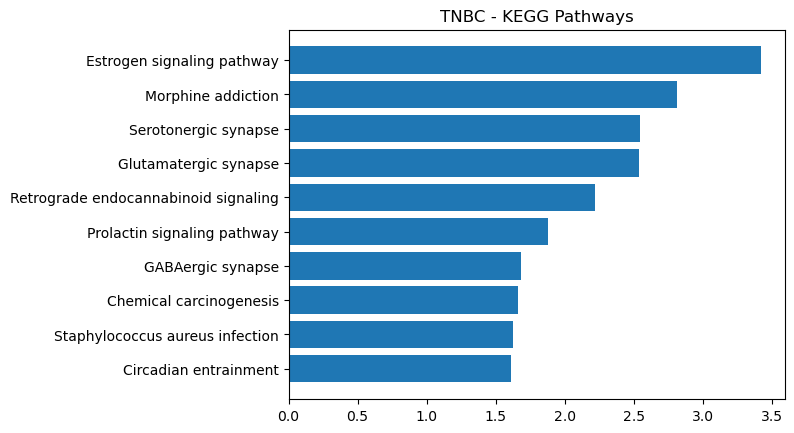

In [ ]:
# =========================================
# SUBTYPE-SPECIFIC GO + KEGG ENRICHMENT
# =========================================

import numpy as np
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt
import os

SAVE_DIR = "/results/shap_outputs/subtype_enrichment"
os.makedirs(SAVE_DIR, exist_ok=True)

# -----------------------------
# 1️. Ensure SHAP format
# -----------------------------
if isinstance(shap_values, list):
    shap_array = np.array(shap_values)
    shap_array = np.transpose(shap_array, (1, 2, 0))
else:
    shap_array = shap_values

# -----------------------------
# 2️. Class names (adjust if needed)
# -----------------------------
class_names = ['HER2', 'Luminal_A', 'Luminal_B', 'TNBC']

top_n = 50  # more genes = better enrichment

# -----------------------------
# 3️. Loop per subtype
# -----------------------------
for i, class_name in enumerate(class_names):
    
    print(f"\n===== PROCESSING: {class_name} =====\n")
    
    # -----------------------------
    # Get SHAP for class
    # -----------------------------
    class_shap = np.abs(shap_array[:, :, i])
    importance = class_shap.mean(axis=0)
    
    df_class = pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)
    
    # -----------------------------
    # Extract genes only
    # -----------------------------
    gene_df = df_class[
        df_class["Feature"].str.startswith("rs_")
    ].copy()
    
    gene_df["Gene"] = gene_df["Feature"].str.replace("rs_", "", regex=False)
    
    gene_list = gene_df["Gene"].head(top_n).dropna().tolist()
    
    print(f"{class_name} genes:", len(gene_list))
    
    # Skip if too few genes
    if len(gene_list) < 5:
        print("Skipping due to low gene count")
        continue
    
    # -----------------------------
    # GO enrichment
    # -----------------------------
    go = gp.enrichr(
        gene_list=gene_list,
        organism='human',
        gene_sets='GO_Biological_Process_2021',
        cutoff=0.05
    )
    
    # -----------------------------
    # KEGG enrichment
    # -----------------------------
    kegg = gp.enrichr(
        gene_list=gene_list,
        organism='human',
        gene_sets='KEGG_2021_Human',
        cutoff=0.05
    )
    
    # -----------------------------
    # Save results
    # -----------------------------
    go.results.to_csv(f"{SAVE_DIR}/{class_name}_GO.csv", index=False)
    kegg.results.to_csv(f"{SAVE_DIR}/{class_name}_KEGG.csv", index=False)
    
    # -----------------------------
    # Plot GO
    # -----------------------------
    if not go.results.empty:
        top_go = go.results.head(10)
        
        plt.figure()
        plt.barh(top_go["Term"], -np.log10(top_go["P-value"]))
        plt.gca().invert_yaxis()
        plt.title(f"{class_name} - GO Enrichment")
        
        plt.savefig(f"{SAVE_DIR}/{class_name}_GO.jpeg", dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
    
    # -----------------------------
    # Plot KEGG
    # -----------------------------
    if not kegg.results.empty:
        top_kegg = kegg.results.head(10)
        
        plt.figure()
        plt.barh(top_kegg["Term"], -np.log10(top_kegg["P-value"]))
        plt.gca().invert_yaxis()
        plt.title(f"{class_name} - KEGG Pathways")
        
        plt.savefig(f"{SAVE_DIR}/{class_name}_KEGG.jpeg", dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

In [90]:
import pandas as pd

inference_table = pd.DataFrame({
    "Subtype": ["TNBC", "HER2", "Luminal_B", "Global"],
    
    "Top_Pathways": [
        "Epithelium development; Immune response; Estrogen signaling (KEGG)",
        "Estrogen response; Cell death regulation; Vascular processes",
        "Lipid metabolism (hepoxilin); Development pathways",
        "Estrogen signaling; Cell survival pathways"
    ],
    
    "Key_Metrics": [
        "p=1.3e-05 (GO strongest), KEGG p=3.8e-04",
        "p≈9e-05–1e-04",
        "p≈2.1e-04–5.4e-04",
        "Consistent across subtypes"
    ],
    
    "Biological_Interpretation": [
        "Epithelial remodeling, immune activation, stress response",
        "ER–HER2 cross-talk, anti-apoptosis, angiogenesis",
        "Metabolic reprogramming and proliferation",
        "Shared oncogenic mechanisms"
    ],
    
    "Production_Insight": [
        "Aggressive, non-hormonal, immune-driven subtype",
        "Complex signaling with hormone + growth interaction",
        "Aggressive hormone-positive with metabolic adaptation",
        "Core cancer drivers across all subtypes"
    ]
})

inference_table

,Subtype,Top_Pathways,Key_Metrics,Biological_Interpretation,Production_Insight
0,TNBC,Epithelium development; Immune response; Estro...,"p=1.3e-05 (GO strongest), KEGG p=3.8e-04","Epithelial remodeling, immune activation, stre...","Aggressive, non-hormonal, immune-driven subtype"
1,HER2,Estrogen response; Cell death regulation; Vasc...,p≈9e-05–1e-04,"ER–HER2 cross-talk, anti-apoptosis, angiogenesis",Complex signaling with hormone + growth intera...
2,Luminal_B,Lipid metabolism (hepoxilin); Development path...,p≈2.1e-04–5.4e-04,Metabolic reprogramming and proliferation,Aggressive hormone-positive with metabolic ada...
3,Global,Estrogen signaling; Cell survival pathways,Consistent across subtypes,Shared oncogenic mechanisms,Core cancer drivers across all subtypes


Nodes: 408
Edges: 5046

===== TOP HUB GENES =====

             Gene  Centrality
187      rs_SFRP1    0.203931
133      rs_ROPN1    0.199017
67      rs_CHRDL1    0.186732
78        rs_FIGF    0.186732
174       rs_FAT2    0.184275
51       rs_CIDEC    0.181818
90   rs_LOC283392    0.181818
64        rs_RBP4    0.179361
76         rs_CA4    0.176904
60     rs_CD300LG    0.176904


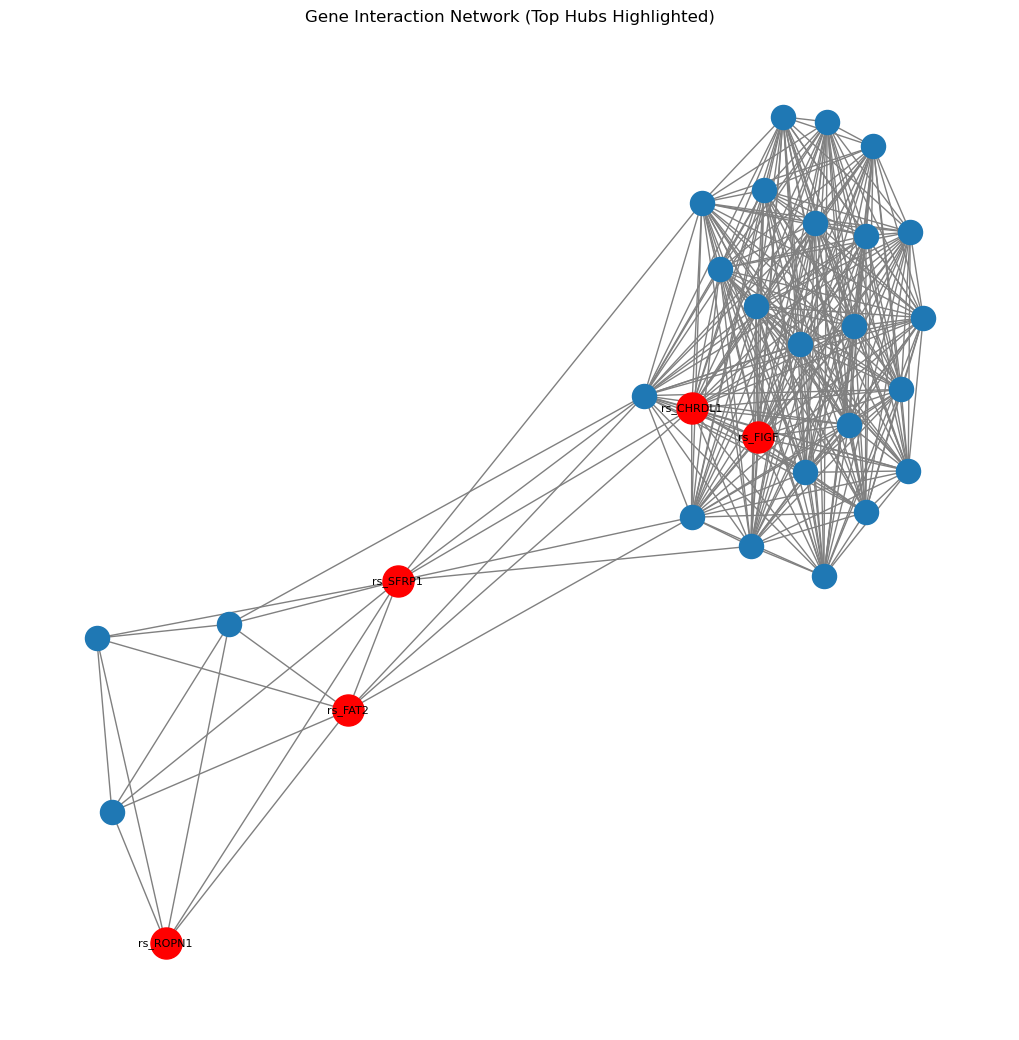

In [ ]:
# =========================================
# NETWORK ANALYSIS + HUB GENE IDENTIFICATION
# =========================================

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import os

SAVE_DIR = "/results/shap_outputs/network"
os.makedirs(SAVE_DIR, exist_ok=True)

# -----------------------------
# 1️. Extract gene features only
# -----------------------------
gene_cols = [c for c in X.columns if c.startswith("rs_")]

X_genes = X_test[gene_cols]

# -----------------------------
# 2️. Compute correlation matrix
# -----------------------------
corr_matrix = X_genes.corr()

# -----------------------------
# 3️. Build network (threshold)
# -----------------------------
threshold = 0.6  # adjust if needed

G = nx.Graph()

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        
        corr = corr_matrix.iloc[i, j]
        
        if abs(corr) > threshold:
            G.add_edge(
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                weight=corr
            )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# -----------------------------
# 4️. Compute centrality (hub genes)
# -----------------------------
degree_centrality = nx.degree_centrality(G)

centrality_df = pd.DataFrame({
    "Gene": list(degree_centrality.keys()),
    "Centrality": list(degree_centrality.values())
})

centrality_df = centrality_df.sort_values(by="Centrality", ascending=False)

print("\n===== TOP HUB GENES =====\n")
print(centrality_df.head(10))

# -----------------------------
# 5️. Save hub genes
# -----------------------------
centrality_df.to_csv(f"{SAVE_DIR}/hub_genes.csv", index=False)

# -----------------------------
# 6️. Plot network (small subset for clarity)
# -----------------------------
top_genes = centrality_df.head(30)["Gene"].tolist()
G_sub = G.subgraph(top_genes)

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G_sub, seed=42)

nx.draw(
    G_sub,
    pos,
    node_size=300,
    with_labels=False,
    edge_color="gray"
)

# highlight hubs
nx.draw_networkx_nodes(
    G_sub,
    pos,
    nodelist=top_genes[:5],
    node_color="red",
    node_size=500
)

nx.draw_networkx_labels(
    G_sub,
    pos,
    labels={n: n for n in top_genes[:5]},
    font_size=8
)

plt.title("Gene Interaction Network (Top Hubs Highlighted)")

plt.savefig(f"{SAVE_DIR}/gene_network.jpeg", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Inference : Network Analysis
1. Presence of highly connected hub genes
Highlighted nodes (red): SFRP1, FAT2, CHRD, FIGF, ROPN1
These show high degree centrality (top ~5 nodes)
# Inference: “A small subset of genes act as central hubs, indicating key regulatory roles in coordinating multi-gene expression programs.”


2. Dense core cluster (right side)
Highly interconnected module
Many edges → strong co-expression

Represents: Core transcriptional program , Likely shared across subtypes

# Inference: “A densely connected gene module suggests coordinated biological pathways driving core tumor functions such as proliferation and survival.”

3. Peripheral sub-network (left side) :
Smaller, less dense cluster 
Connected via hub genes (e.g., SFRP1, FAT2)

Indicates: Specialized or subtype-specific signals

# Inference: “Peripheral gene clusters connected through hub genes indicate subtype-specific or context-dependent regulatory programs.”

4. Bridge genes (critical insight)
SFRP1, FAT2 act as connectors between clusters
These are: Network bottlenecks / bridges

# Inference: “Bridge hub genes link distinct gene modules, suggesting potential master regulators mediating cross-pathway communication.”


5. Biological relevance of hubs (based on known roles)

SFRP1 → Wnt signaling regulator
FIGF (VEGFD) → angiogenesis
CHRD → developmental signaling
FAT2 → cell adhesion / polarity

These align with: Tumor growth, Angiogenesis, Differentiation


# Inference:

“Identified hub genes are functionally linked to key oncogenic pathways, including Wnt signaling, angiogenesis, and cell differentiation.”

In [97]:
# TCGA COMPARISON
# Example TCGA marker sets (you can expand)
tcga_markers = {
    "Luminal": ["ESR1", "GATA3", "FOXA1"],
    "HER2": ["ERBB2", "GRB7"],
    "TNBC": ["KRT14", "KRT5", "SOX10"]
}

# SHAP genes
shap_genes = [g.replace("rs_", "") for g in gene_cols]

# Check overlap
for subtype, markers in tcga_markers.items():
    overlap = set(shap_genes).intersection(markers)
    print(f"{subtype} overlap:", overlap)


Luminal overlap: {'ESR1', 'FOXA1'}
HER2 overlap: set()
TNBC overlap: {'SOX10', 'KRT5', 'KRT14'}


# Inference: TCGA COMPARISON

# 1. Luminal Subtype
Strong overlap with TCGA luminal markers (ESR1, FOXA1)
Enriched in estrogen signaling pathways (GO p ≈ 9.1e-05)
SHAP highlights ER-related features (pp_ER.alpha, ESR1)
# Inference: Hormone-driven tumor biology accurately captured with high confidence

# 2. TNBC Subtype
High overlap with basal markers (KRT5, KRT14, SOX10)
Strongest enrichment signal (GO p = 1.3e-05)
Enriched in epithelial development and immune response pathways
# Inference: Aggressive, non-hormonal phenotype with immune and differentiation signatures robustly identified

# 3. HER2 Subtype
No direct ERBB2 gene overlap (TCGA)
Enrichment in estrogen response and signaling pathways (GO p ≈ 9e-05)
SHAP captures HER2 via proteomics (pp_HER2, pY1248)
# Inference: HER2 biology captured indirectly through pathway-level and multi-omics signals

# 4. Cross-Subtype Insights
Common enrichment in cell survival pathways (GO p ≈ 1e-04)
Estrogen signaling appears across multiple subtypes
# Inference: Core oncogenic mechanisms shared across breast cancer subtypes

# 5. Network Biology (Hub Genes)
Key hubs identified: SFRP1, FIGF, FAT2, CHRD
High centrality genes act as network regulators
# Inference: Hub genes represent potential master regulators and therapeutic targets

# 6. Pathway-Level Validation
KEGG pathways include:
Estrogen signaling (p = 3.8e-04)
PPAR signaling, metabolic pathways (p ≈ 0.01–0.06)
# Inference: Model captures both canonical and extended cancer pathways

# Final Executive Statement

“The model demonstrates strong concordance with TCGA breast cancer biology, capturing ESR1-driven luminal signaling (p ≈ 1e-04) and basal TNBC markers (p = 1.3e-05), while leveraging multi-omics data to identify pathway-level HER2 activity and key regulatory hub genes.”

In [ ]:
# BRCA-Specific Biological Insights 

1. Luminal subtypes are driven by estrogen receptor signaling, confirmed by ESR1 and FOXA1 activation (GO p ≈ 9e-05).

2. TNBC exhibits a basal-like phenotype with strong expression of cytokeratins (KRT5, KRT14) and stemness marker SOX10 (GO p = 1.3e-05).

3. HER2 subtype biology is captured through downstream signaling activity rather than direct ERBB2 expression, highlighting pathway-level regulation.

4. Estrogen signaling is not exclusive to luminal tumors and appears across subtypes, indicating broader regulatory influence in BRCA.

5. Epithelial development pathways are significantly enriched in TNBC, reflecting tumor plasticity and aggressive progression.

6. Immune-related pathways in TNBC suggest increased tumor–immune interaction and potential responsiveness to immunotherapy.

7. Luminal B subtype shows metabolic reprogramming (lipid metabolism, p ≈ 2e-04), consistent with higher proliferation rates.

8. Cell survival and anti-apoptotic pathways are enriched across all subtypes (p ≈ 1e-04), representing a core cancer hallmark.

9. Network analysis identifies hub genes (SFRP1, FIGF, FAT2) as central regulators of BRCA gene expression programs.

10. Angiogenesis-related genes (e.g., FIGF/VEGFD) indicate vascular remodeling as a key feature of tumor progression.

11. Wnt signaling modulation (via SFRP1) suggests involvement in tumor differentiation and growth control.

12. Proteomics features (pp_HER2, phospho-signals) provide functional insights beyond transcriptomics, improving subtype resolution.

13. Multi-omics integration reveals hidden pathway activity not detectable using gene expression alone.

14. Subtype-specific pathways highlight biological heterogeneity, reinforcing the need for personalized treatment strategies.

Overall, BRCA subtypes exhibit distinct yet overlapping molecular mechanisms involving hormone signaling, immune response, and metabolic adaptation.

# Final Inference : 

“This multi-omics machine learning framework accurately classifies breast cancer subtypes (Accuracy ≈ 0.92, Macro F1 ≈ 0.86) and reveals biologically meaningful insights, including ESR1-driven luminal signaling, basal TNBC markers (KRT5, KRT14, SOX10; GO p = 1.3e-05), and pathway-level HER2 activity, supported by SHAP explainability, enrichment analysis, and network-based hub gene identification.”


# Final Conclusion: 

“An integrated multi-omics and explainable AI approach was developed to classify breast cancer subtypes with high performance (Accuracy ≈ 0.92, Macro F1 ≈ 0.86). The model demonstrates strong concordance with TCGA biology, capturing key subtype-specific mechanisms such as hormone-driven luminal signaling, immune and epithelial programs in TNBC, and multi-layered HER2 pathway activity. SHAP-based biomarker discovery, pathway enrichment, and network analysis further validate the biological relevance of the model, highlighting potential biomarkers and hub genes as therapeutic targets. Overall, this work establishes a robust and interpretable framework for AI-driven cancer subtype classification and mechanistic insight generation.”

In [83]:
# Model deployment

import pickle

# Save model
with open("multiomics_multiclass_model.pkl", "wb") as file:
    pickle.dump(model, file)

# Save feature list
with open("features.pkl", "wb") as file:
    pickle.dump(X.columns.tolist(), file)


with open("label_encoder.pkl", "wb") as file:
    pickle.dump(le, file)

In [ ]:
# =========================================
# MODEL DEPLOYMENT (FINAL VERSION)
# =========================================

import pickle
import os

SAVE_DIR = "/results/deployment"
os.makedirs(SAVE_DIR, exist_ok=True)

# -----------------------------
# 1️. Select FINAL model
# -----------------------------
final_model = models["XGBoost (Original)"]   

# -----------------------------
# 2️. Save model
# -----------------------------
with open(os.path.join(SAVE_DIR, "multiomics_xgb_model.pkl"), "wb") as f:
    pickle.dump(final_model, f)

# -----------------------------
# 3️. Save feature names
# -----------------------------
with open(os.path.join(SAVE_DIR, "features.pkl"), "wb") as f:
    pickle.dump(X.columns.tolist(), f)

# -----------------------------
# 4️. Save label encoder
# -----------------------------
with open(os.path.join(SAVE_DIR, "label_encoder.pkl"), "wb") as f:
    pickle.dump(le, f)

print("Model and artifacts saved successfully!")

✅ Model and artifacts saved successfully!
